# Applied Statistics for Data Science


# Chapter 2: Distribution Families & Shapes

by Gal Arav M.Sc. © 2026  
Licensed under the MIT LICENSE

## Learning Objectives  

This notebook accompanies the book's Chapter 2 with these objectives:

- Distinguish between bounded and unbounded support in both discrete and continuous settings.
- Describe the structure of single‑parameter, two‑parameter, and three‑parameter distribution families.
- Interpret how distribution parameters influence shape, skewness, tail weight, and modality.
- Compare distributions using conceptual contrasts such as symmetry, tail behavior, modality, and waiting‑time characteristics.
- Recognize the differences between memoryless and aging processes and how they appear in data.
- Understand the role of survival curves and hazard rates in analyzing time‑to‑event behavior.
- Understand multivariate distributions and variable relationships, including joint, marginal, and conditional behavior, covariance and correlation, and the role of independence.


In [ ]:
# Utility function to save a high‑resolution figure for the textbook
# Images are saved temporarily in Google Colab and disappear when the session ends
import matplotlib.pyplot as plt
import os

def export_plot(fig, plot_id, dpi=300, width=8, height=5, outdir="exports"):
    fig.set_size_inches(width, height)
    fig.subplots_adjust(left=0.12, right=0.95, top=0.87, bottom=0.15)
    os.makedirs(outdir, exist_ok=True)
    fig.savefig(f"{outdir}/{plot_id}.png", dpi=dpi, bbox_inches=None, pad_inches=0.45)

## Support and Boundedness

### Continuous Bounded Distributions

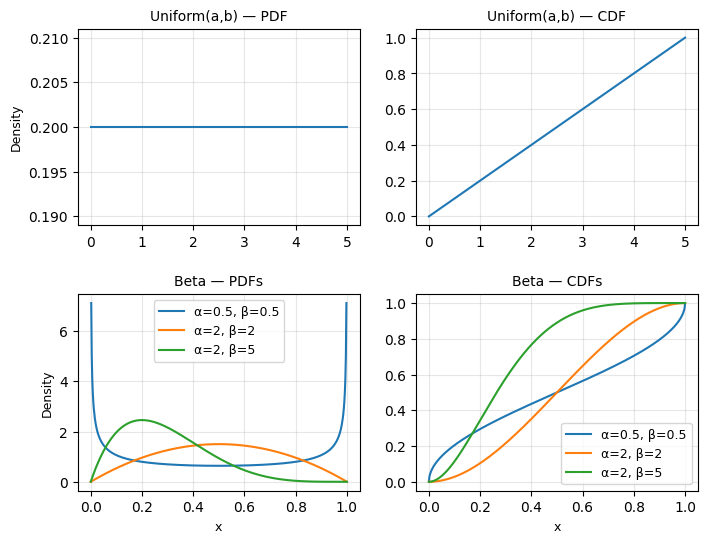

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform, beta

# --- Create figure properly so export_plot works ---
fig, axes = plt.subplots(2, 2, figsize=(8, 6), gridspec_kw={"hspace": 0.35})

n_rows, n_cols = axes.shape

# ============================================================
# Uniform Distribution (bounded [a,b])
# ============================================================
a, b = 0, 5
grid_uni = np.linspace(a, b, 500)

axes[0,0].plot(grid_uni, uniform.pdf(grid_uni, loc=a, scale=b-a))
axes[0,0].set_title("Uniform(a,b) — PDF", fontsize=10)
axes[0,0].set_ylabel("Density", fontsize=9)
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(grid_uni, uniform.cdf(grid_uni, loc=a, scale=b-a))
axes[0,1].set_title("Uniform(a,b) — CDF", fontsize=10)
axes[0,1].grid(True, alpha=0.3)

# ============================================================
# Beta Distribution (bounded [0,1])
# ============================================================
alpha_beta_pairs = [(0.5, 0.5), (2, 2), (2, 5)]
grid_beta = np.linspace(0, 1, 500)

for a_b, b_b in alpha_beta_pairs:
    axes[1,0].plot(grid_beta, beta.pdf(grid_beta, a_b, b_b), label=f"α={a_b}, β={b_b}")
axes[1,0].set_title("Beta — PDFs", fontsize=10)
axes[1,0].set_xlabel("x", fontsize=9)
axes[1,0].set_ylabel("Density", fontsize=9)
axes[1,0].grid(True, alpha=0.3)
axes[1,0].legend(fontsize=9)

for a_b, b_b in alpha_beta_pairs:
    axes[1,1].plot(grid_beta, beta.cdf(grid_beta, a_b, b_b), label=f"α={a_b}, β={b_b}")
axes[1,1].set_title("Beta — CDFs", fontsize=10)
axes[1,1].set_xlabel("x", fontsize=9)
axes[1,1].grid(True, alpha=0.3)
axes[1,1].legend(fontsize=9)

# ============================================================
# AXIS CLEANUP RULES
# ============================================================

# 1. Remove x‑labels from all rows except the last
for r in range(n_rows - 1):
    for c in range(n_cols):
        axes[r, c].set_xlabel("")

# 2. Remove y‑labels from second column
for r in range(n_rows):
    axes[r, 1].set_ylabel("")

plt.show()

# Multi‑row → height=7
export_plot(fig, "sim_continuous_bounded", height=7)

### Discrete Bounded Distributions

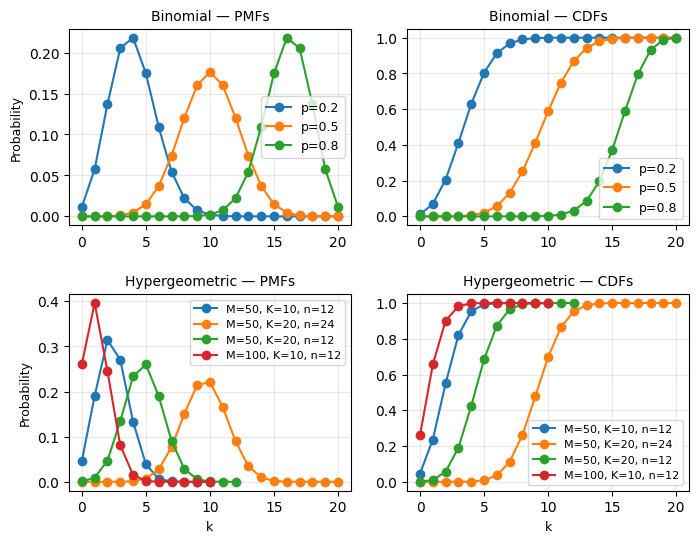

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, hypergeom

# --- Create figure properly so export_plot works ---
fig, axes = plt.subplots(2, 2, figsize=(8, 6), gridspec_kw={"hspace": 0.35})

n_rows, n_cols = axes.shape

# ============================================================
# Binomial Distribution (bounded {0,...,n})
# ============================================================
n = 20
ps = [0.2, 0.5, 0.8]
grid_bin = np.arange(0, n+1)

for p in ps:
    axes[0,0].plot(grid_bin, binom.pmf(grid_bin, n, p), marker='o', label=f"p={p}")
axes[0,0].set_title("Binomial — PMFs", fontsize=10)
axes[0,0].set_ylabel("Probability", fontsize=9)
axes[0,0].grid(True, alpha=0.3)
axes[0,0].legend(fontsize=9)

for p in ps:
    axes[0,1].plot(grid_bin, binom.cdf(grid_bin, n, p), marker='o', label=f"p={p}")
axes[0,1].set_title("Binomial — CDFs", fontsize=10)
axes[0,1].grid(True, alpha=0.3)
axes[0,1].legend(fontsize=9)

# ============================================================
# Hypergeometric Distribution
# ============================================================
params = [
    (50, 10, 12),
    (50, 20, 24),
    (50, 20, 12),
    (100, 10, 12)
]

for M, K, n_draws in params:
    support_min = max(0, n_draws - (M - K))
    support_max = min(n_draws, K)
    grid_hyp = np.arange(support_min, support_max + 1)

    axes[1,0].plot(grid_hyp, hypergeom.pmf(grid_hyp, M, K, n_draws),
                   marker='o', label=f"M={M}, K={K}, n={n_draws}")

axes[1,0].set_title("Hypergeometric — PMFs", fontsize=10)
axes[1,0].set_xlabel("k", fontsize=9)
axes[1,0].set_ylabel("Probability", fontsize=9)
axes[1,0].grid(True, alpha=0.3)
axes[1,0].legend(fontsize=8)

for M, K, n_draws in params:
    support_min = max(0, n_draws - (M - K))
    support_max = min(n_draws, K)
    grid_hyp = np.arange(support_min, support_max + 1)

    axes[1,1].plot(grid_hyp, hypergeom.cdf(grid_hyp, M, K, n_draws),
                   marker='o', label=f"M={M}, K={K}, n={n_draws}")

axes[1,1].set_title("Hypergeometric — CDFs", fontsize=10)
axes[1,1].set_xlabel("k", fontsize=9)
axes[1,1].grid(True, alpha=0.3)
axes[1,1].legend(fontsize=8)

# ============================================================
# AXIS CLEANUP RULES
# ============================================================

# 1. Remove x‑labels from all rows except the last
for r in range(n_rows - 1):
    for c in range(n_cols):
        axes[r, c].set_xlabel("")

# 2. Remove y‑labels from second column
for r in range(n_rows):
    axes[r, 1].set_ylabel("")

plt.show()

# Multi‑row → height=7
export_plot(fig, "sim_discrete_bounded", height=7)

### Summary

| Feature | **Uniform** | **Beta** | **Binomial** | **Hypergeometric** |
|--------|-------------|----------|--------------|---------------------|
| **Type** | Continuous | Continuous | Discrete | Discrete |
| **Parameters** | a, b (bounds) | α, β (shape) | n (trials), p (success prob) | M (population), K (successes), n (draws) |
| **Mean** | (a + b) / 2 | α / (α + β) | np | n·(K/M) |
| **Std. Dev.** | (b − a)/√12 | √[αβ / ((α+β)²(α+β+1))] | √(np(1−p)) | √[n(K/M)(1−K/M)((M−n)/(M−1))] |
| **Shape** | Flat, constant density | Highly flexible: symmetric, skewed, U‑shaped | Bell‑shaped when p≈0.5, skewed otherwise | Depends on population composition and sample size |
| **Support** | a ≤ x ≤ b | 0 ≤ x ≤ 1 | k = 0,1,…,n | k = max(0, n−(M−K)) … min(n, K) |
| **PDF / PMF** | 1/(b−a) | Proportional to x^(α−1)(1−x)^(β−1) | C(n,k)p^k(1−p)^(n−k) | [C(K,k)C(M−K,n−k)] / C(M,n) |
| **Typical Uses** | Baselines, simulations, randomization | Probabilities, proportions, Bayesian priors | Counts of successes, quality control | Sampling without replacement, finite populations |

## Distributions With a Single Parameter

### Count-Based Single Parameter Distributions

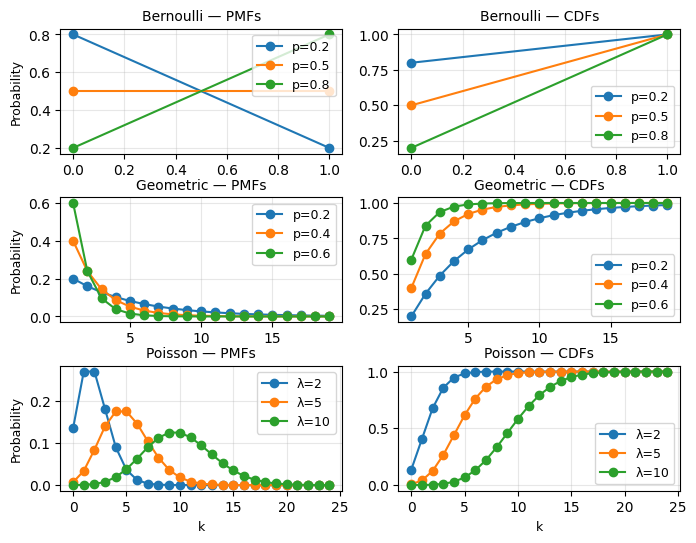

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, bernoulli, geom

# --- Create figure properly so export_plot works ---
fig, axes = plt.subplots(3, 2, figsize=(8, 6), gridspec_kw={"hspace": 0.35})

n_rows, n_cols = axes.shape

# ============================================================
# 1. Bernoulli  (Row 1)
# ============================================================
ps_bern = [0.2, 0.5, 0.8]
grid_bern = np.array([0, 1])

for p in ps_bern:
    axes[0,0].plot(grid_bern, bernoulli.pmf(grid_bern, p), marker='o', label=f"p={p}")
axes[0,0].set_title("Bernoulli — PMFs", fontsize=10)
axes[0,0].set_ylabel("Probability", fontsize=9)
axes[0,0].grid(True, alpha=0.3)
axes[0,0].legend(fontsize=9)

for p in ps_bern:
    axes[0,1].plot(grid_bern, bernoulli.cdf(grid_bern, p), marker='o', label=f"p={p}")
axes[0,1].set_title("Bernoulli — CDFs", fontsize=10)
axes[0,1].grid(True, alpha=0.3)
axes[0,1].legend(fontsize=9)

# ============================================================
# 2. Geometric  (Row 2)
# ============================================================
ps_geo = [0.2, 0.4, 0.6]
grid_geo = np.arange(1, 20)

for p in ps_geo:
    axes[1,0].plot(grid_geo, geom.pmf(grid_geo, p), marker='o', label=f"p={p}")
axes[1,0].set_title("Geometric — PMFs", fontsize=10)
axes[1,0].set_ylabel("Probability", fontsize=9)
axes[1,0].grid(True, alpha=0.3)
axes[1,0].legend(fontsize=9)

for p in ps_geo:
    axes[1,1].plot(grid_geo, geom.cdf(grid_geo, p), marker='o', label=f"p={p}")
axes[1,1].set_title("Geometric — CDFs", fontsize=10)
axes[1,1].grid(True, alpha=0.3)
axes[1,1].legend(fontsize=9)

# ============================================================
# 3. Poisson  (Row 3)
# ============================================================
lambdas = [2, 5, 10]
grid_pois = np.arange(0, 25)

for lam in lambdas:
    axes[2,0].plot(grid_pois, poisson.pmf(grid_pois, lam), marker='o', label=f"λ={lam}")
axes[2,0].set_title("Poisson — PMFs", fontsize=10)
axes[2,0].set_xlabel("k", fontsize=9)
axes[2,0].set_ylabel("Probability", fontsize=9)
axes[2,0].grid(True, alpha=0.3)
axes[2,0].legend(fontsize=9)

for lam in lambdas:
    axes[2,1].plot(grid_pois, poisson.cdf(grid_pois, lam), marker='o', label=f"λ={lam}")
axes[2,1].set_title("Poisson — CDFs", fontsize=10)
axes[2,1].set_xlabel("k", fontsize=9)
axes[2,1].grid(True, alpha=0.3)
axes[2,1].legend(fontsize=9)

# ============================================================
# AXIS CLEANUP RULES
# ============================================================

# 1. Remove x‑labels from all rows except the last
for r in range(n_rows - 1):
    for c in range(n_cols):
        axes[r, c].set_xlabel("")

# 2. Remove y‑labels from second column
for r in range(n_rows):
    axes[r, 1].set_ylabel("")

plt.show()

# Multi‑row → height=7
export_plot(fig, "sim_count_based", height=7)

#### Summary

| **Feature**       | **Bernoulli** | **Geometric** | **Poisson** |
|-------------------|----------------|----------------|--------------|
| **Type**          | Discrete       | Discrete       | Discrete     |
| **Parameter**     | Probability p (0.2, 0.5, 0.8) | Probability p (0.2, 0.4, 0.6) | Rate λ (2, 5, 10) |
| **Mean**          | p             | 1/p            | λ            |
| **Std. Dev.**     | √(p(1−p))     | √(1−p)/p       | √λ           |
| **Shape**         | Two‑point distribution (0 or 1) | Decreasing geometric sequence | Unimodal; shifts right as λ increases |
| **Support**       | k = 0,1       | k = 1,2,3,…    | k = 0,1,2,…  |
| **PMF**           | p^k (1−p)^(1−k) | p(1−p)^(k−1) | e^(−λ) λ^k / k! |
| **Typical Uses**  | Binary outcomes, success/failure | Trials until first success | Event counts in time/space |
| **Notes**         | Simplest discrete distribution | Memoryless | From Poisson process |

### Survival or Waiting-Time Single Parameter Distributions

- A waiting‑time model tells you when failures tend to occur.
- A survival curve tells you how many units are still functioning at each time.
- A hazard rate tells you how risk evolves (memoryless, aging, early failures, etc.).

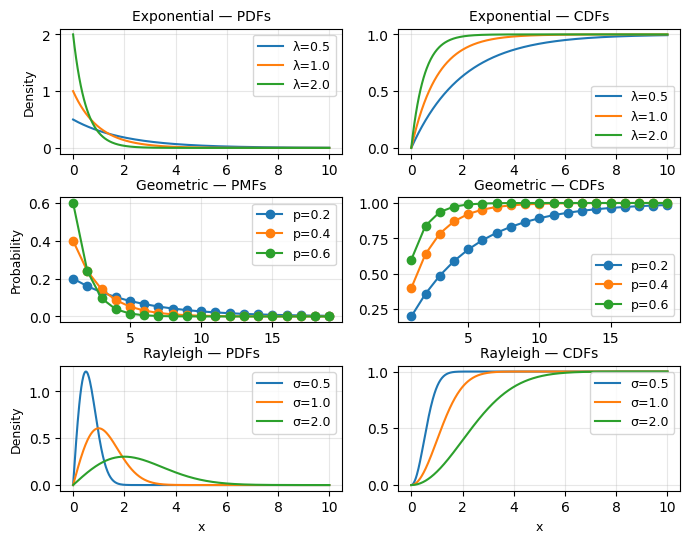

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon, geom, rayleigh

# --- Create figure properly so export_plot works ---
fig, axes = plt.subplots(3, 2, figsize=(8, 6), gridspec_kw={"hspace": 0.35})

n_rows, n_cols = axes.shape

# ============================================================
# 1. Exponential
# ============================================================
lambdas = [0.5, 1.0, 2.0]
grid_exp = np.linspace(0, 10, 500)

# PDF
for lam in lambdas:
    axes[0,0].plot(grid_exp, expon.pdf(grid_exp, scale=1/lam), label=f"λ={lam}")
axes[0,0].set_title("Exponential — PDFs", fontsize=10)
axes[0,0].set_ylabel("Density", fontsize=9)
axes[0,0].grid(True, alpha=0.3)
axes[0,0].legend(fontsize=9)

# CDF
for lam in lambdas:
    axes[0,1].plot(grid_exp, expon.cdf(grid_exp, scale=1/lam), label=f"λ={lam}")
axes[0,1].set_title("Exponential — CDFs", fontsize=10)
axes[0,1].grid(True, alpha=0.3)
axes[0,1].legend(fontsize=9)

# ============================================================
# 2. Geometric (discrete)
# ============================================================
ps = [0.2, 0.4, 0.6]
grid_geo = np.arange(1, 20)

# PMF
for p in ps:
    axes[1,0].plot(grid_geo, geom.pmf(grid_geo, p), marker='o', label=f"p={p}")
axes[1,0].set_title("Geometric — PMFs", fontsize=10)
axes[1,0].set_ylabel("Probability", fontsize=9)
axes[1,0].grid(True, alpha=0.3)
axes[1,0].legend(fontsize=9)

# CDF
for p in ps:
    axes[1,1].plot(grid_geo, geom.cdf(grid_geo, p), marker='o', label=f"p={p}")
axes[1,1].set_title("Geometric — CDFs", fontsize=10)
axes[1,1].grid(True, alpha=0.3)
axes[1,1].legend(fontsize=9)

# ============================================================
# 3. Rayleigh
# ============================================================
sigmas = [0.5, 1.0, 2.0]
grid_ray = np.linspace(0, 10, 500)

# PDF
for s in sigmas:
    axes[2,0].plot(grid_ray, rayleigh.pdf(grid_ray, scale=s), label=f"σ={s}")
axes[2,0].set_title("Rayleigh — PDFs", fontsize=10)
axes[2,0].set_xlabel("x", fontsize=9)
axes[2,0].set_ylabel("Density", fontsize=9)
axes[2,0].grid(True, alpha=0.3)
axes[2,0].legend(fontsize=9)

# CDF
for s in sigmas:
    axes[2,1].plot(grid_ray, rayleigh.cdf(grid_ray, scale=s), label=f"σ={s}")
axes[2,1].set_title("Rayleigh — CDFs", fontsize=10)
axes[2,1].set_xlabel("x", fontsize=9)
axes[2,1].grid(True, alpha=0.3)
axes[2,1].legend(fontsize=9)

# ============================================================
# AXIS CLEANUP RULES
# ============================================================

# 1. Remove x‑labels from all rows except the last
for r in range(n_rows - 1):
    for c in range(n_cols):
        axes[r, c].set_xlabel("")

# 2. Remove y‑labels from second column
for r in range(n_rows):
    axes[r, 1].set_ylabel("")

plt.show()

# Multi‑row → height=7
export_plot(fig, "sim_survival_waiting_time", height=7)

#### Summary

| Feature | **Exponential** | **Geometric** | **Rayleigh** |
|--------|------------------|----------------|----------------|
| **Type** | Continuous | Discrete | Continuous |
| **Parameter** | Rate λ (0.5, 1.0, 2.0) | Probability p (0.2, 0.4, 0.6) | Scale σ (0.5, 1.0, 2.0) |
| **Mean** | 1/λ | (1−p)/p | σ√(π/2) |
| **Std. Dev.** | 1/λ | √(1−p)/p | σ√((4−π)/2) |
| **Shape** | Rapidly decaying from max at x=0 | Decreasing geometric sequence | Rises linearly then decays (unimodal) |
| **Hazard Rate** | Constant | Increasing | Increasing |
| **Memoryless?** | Yes | Yes | No |
| **Support** | x ≥ 0 | k = 1,2,3,… | x ≥ 0 |
| **PDF** | λ e^(−λx) | Not applicable (discrete) | (x/σ²) e^(−x²/(2σ²)) |
| **PMF** | Not applicable (continuous) | p(1−p)^(k−1) | Not applicable (continuous) |
| **Typical Uses** | Waiting times, Poisson processes, reliability | Trials until first success | Wind speeds, signal fading, magnitude of 2D Gaussian vector |

## Distributions With 2 Parameters

### Normal Distribution

The normal distribution is the classic bell‑shaped model used to describe natural variation, measurement noise, and many aggregated random processes.  

- Symmetric around its mean
- Single peak (unimodal)
- Light‑tailed compared to heavy‑tailed alternatives
- Shape controlled by mean (location) and standard deviation (spread)
- Smooth, bell‑shaped curve with no skew
- Common in statistics due to the central limit effect
- Used for modeling measurement errors, natural fluctuations, and many real‑world continuous variables


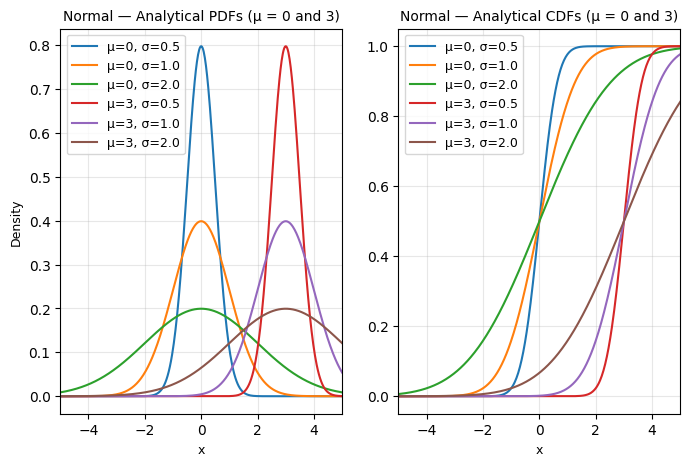

In [ ]:
# ============================================================
# Normal Distribution (μ = 0 and μ = 3 for range of σ)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

mus = [0, 3]
sigmas = [0.5, 1.0, 2.0]

grid = np.linspace(-5, 5, 500)

# --- Create figure properly so export_plot works ---
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

# ============================================================
# LEFT: PDFs
# ============================================================
for mu in mus:
    for sigma in sigmas:
        label = f"μ={mu}, σ={sigma}"
        pdf_vals = stats.norm.pdf(grid, loc=mu, scale=sigma)
        axes[0].plot(grid, pdf_vals, label=label)

axes[0].set_title("Normal — Analytical PDFs (μ = 0 and 3)", fontsize=10)
axes[0].set_xlabel("x", fontsize=9)
axes[0].set_ylabel("Density", fontsize=9)
axes[0].set_xlim(-5, 5)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9, ncol=1)

# ============================================================
# RIGHT: CDFs
# ============================================================
for mu in mus:
    for sigma in sigmas:
        label = f"μ={mu}, σ={sigma}"
        cdf_vals = stats.norm.cdf(grid, loc=mu, scale=sigma)
        axes[1].plot(grid, cdf_vals, label=label)

axes[1].set_title("Normal — Analytical CDFs (μ = 0 and 3)", fontsize=10)
axes[1].set_xlabel("x", fontsize=9)
axes[1].set_ylabel("")  # remove y-label for second column
axes[1].set_xlim(-5, 5)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9, ncol=1)

plt.show()

# Single row → no height override needed, but allowed
export_plot(fig, "sim_normal")

### Lognormal Distribution

The lognormal distribution models positive quantities that grow multiplicatively, producing strong right‑skew and heavy upper tails.  
- Always positive; defined only for x > 0
- Strongly right‑skewed with a long upper tail
- Shape controlled by log‑mean and log‑standard‑deviation
- Represents multiplicative growth rather than additive variation
- Hazard rate increases over time (an aging distribution)
- Useful for modeling incomes, asset prices, lifetimes with wear‑out, and multiplicative processes


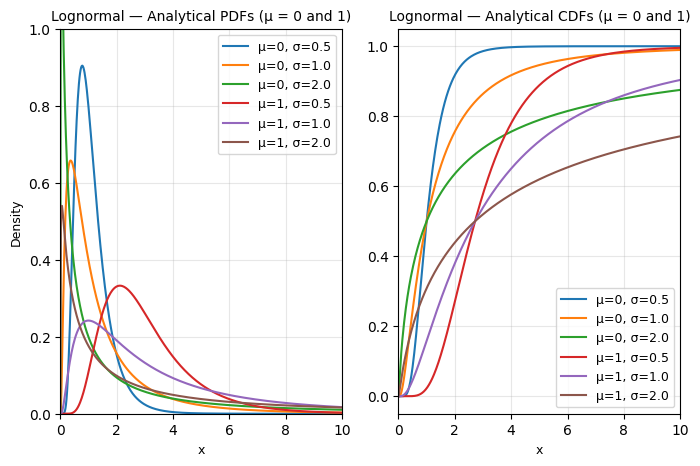

In [ ]:
# ============================================================
# Lognormal Distribution (μ = 0 and μ = 1 for range of σ)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

mus = [0, 1]
sigmas = [0.5, 1.0, 2.0]

grid = np.linspace(0, 10, 500)   # lognormal support is x > 0

# --- Create figure properly so export_plot works ---
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

# ============================================================
# LEFT: PDFs
# ============================================================
for mu in mus:
    for sigma in sigmas:
        label = f"μ={mu}, σ={sigma}"
        pdf_vals = stats.lognorm.pdf(grid, s=sigma, scale=np.exp(mu))
        axes[0].plot(grid, pdf_vals, label=label)

axes[0].set_title("Lognormal — Analytical PDFs (μ = 0 and 1)", fontsize=10)
axes[0].set_xlabel("x", fontsize=9)
axes[0].set_ylabel("Density", fontsize=9)
axes[0].set_xlim(0, 10)
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9, ncol=1)

# ============================================================
# RIGHT: CDFs
# ============================================================
for mu in mus:
    for sigma in sigmas:
        label = f"μ={mu}, σ={sigma}"
        cdf_vals = stats.lognorm.cdf(grid, s=sigma, scale=np.exp(mu))
        axes[1].plot(grid, cdf_vals, label=label)

axes[1].set_title("Lognormal — Analytical CDFs (μ = 0 and 1)", fontsize=10)
axes[1].set_xlabel("x", fontsize=9)
axes[1].set_ylabel("")  # remove y-label for second column
axes[1].set_xlim(0, 10)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9, ncol=1)

plt.show()

export_plot(fig, "sim_lognormal")

### Gamma Distribution

The Gamma distribution models positive quantities that accumulate additively across multiple exponential‑like stages, producing flexible right‑skewed shapes.  

- Always positive; defined only for x>0
- Flexible right‑skewed shape that ranges from exponential‑like to nearly symmetric
- Shape controlled by shape k (or alpha ) and scale theta
- Represents additive waiting times (sum of k exponential stages)
- Hazard rate can increase, decrease, or remain constant depending on k
- Useful for modeling lifetimes, waiting times, rainfall amounts, insurance claims, and multi‑stage processes



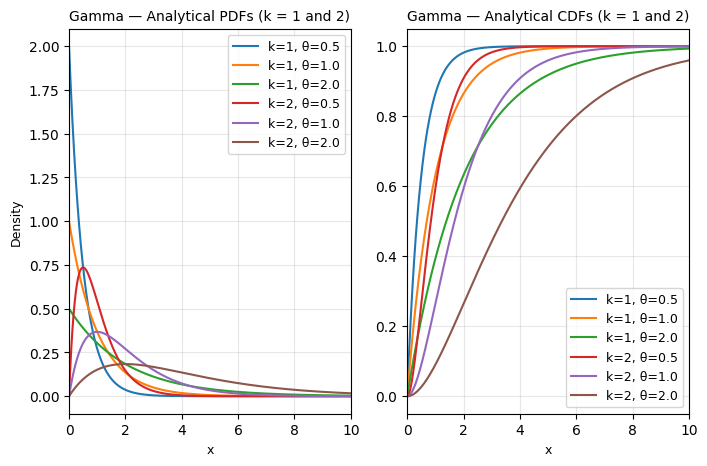

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ============================================================
# Gamma Distribution (k = 1, 2 for range of θ)
# ============================================================

shapes = [1, 2]          # k (shape)
scales = [0.5, 1.0, 2.0] # θ (scale)

grid = np.linspace(0, 10, 500)   # gamma support is x > 0

# --- Create figure properly so export_plot works ---
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

# ============================================================
# LEFT: PDFs
# ============================================================
for k in shapes:
    for theta in scales:
        label = f"k={k}, θ={theta}"
        pdf_vals = stats.gamma.pdf(grid, a=k, scale=theta)
        axes[0].plot(grid, pdf_vals, label=label)

axes[0].set_title("Gamma — Analytical PDFs (k = 1 and 2)", fontsize=10)
axes[0].set_xlabel("x", fontsize=9)
axes[0].set_ylabel("Density", fontsize=9)
axes[0].set_xlim(0, 10)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9, ncol=1)

# ============================================================
# RIGHT: CDFs
# ============================================================
for k in shapes:
    for theta in scales:
        label = f"k={k}, θ={theta}"
        cdf_vals = stats.gamma.cdf(grid, a=k, scale=theta)
        axes[1].plot(grid, cdf_vals, label=label)

axes[1].set_title("Gamma — Analytical CDFs (k = 1 and 2)", fontsize=10)
axes[1].set_xlabel("x", fontsize=9)
axes[1].set_ylabel("")  # remove y-label for second column
axes[1].set_xlim(0, 10)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9, ncol=1)

plt.show()

export_plot(fig, "sim_gamma")


### Negative Binomial Distribution

The Negative Binomial distribution is the discrete counterpart to the Gamma, modeling counts that accumulate across multiple geometric-like stages to produce flexible right-skewed patterns.

- Always non-negative; defined only for discrete integers k >= 0
- Flexible right-skewed shape that ranges from geometric-like to nearly symmetric
- Shape controlled by the number of successes r (or size) and probability p
- Represents additive waiting times (the sum of r independent geometric trials)
- Variance exceeds the mean, providing a more flexible alternative to the Poisson for overdispersed data
- Useful for modeling accident counts, species abundance, genomic sequencing reads, and marketing purchase frequencies



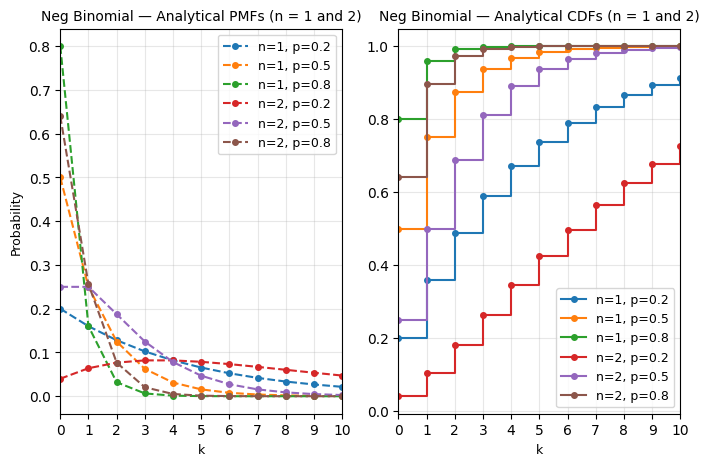

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ============================================================
# Negative Binomial Distribution (n = 1, 2 for range of p)
# ============================================================

shapes = [1, 2]            # n (number of successes)
probs = [0.2, 0.5, 0.8]    # p (probability of success)

grid = np.arange(0, 11)    # NB support is discrete k >= 0

# --- Create figure properly so export_plot works ---
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

# ============================================================
# LEFT: PMFs
# ============================================================
for n in shapes:
    for p in probs:
        label = f"n={n}, p={p}"
        pmf_vals = stats.nbinom.pmf(grid, n=n, p=p)
        axes[0].plot(grid, pmf_vals, 'o--', markersize=4, label=label)

axes[0].set_title("Neg Binomial — Analytical PMFs (n = 1 and 2)", fontsize=10)
axes[0].set_xlabel("k", fontsize=9)
axes[0].set_ylabel("Probability", fontsize=9)
axes[0].set_xticks(grid)
axes[0].set_xlim(0, 10)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9, ncol=1)

# ============================================================
# RIGHT: CDFs
# ============================================================
for n in shapes:
    for p in probs:
        label = f"n={n}, p={p}"
        cdf_vals = stats.nbinom.cdf(grid, n=n, p=p)
        axes[1].step(grid, cdf_vals, where='post', marker='o', markersize=4, label=label)

axes[1].set_title("Neg Binomial — Analytical CDFs (n = 1 and 2)", fontsize=10)
axes[1].set_xlabel("k", fontsize=9)
axes[1].set_ylabel("")  # remove y-label for second column
axes[1].set_xticks(grid)
axes[1].set_xlim(0, 10)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9, ncol=1)

plt.show()

export_plot(fig, "sim_negative_binomial")

## Distributions With 3 Parameters

Distributions with 3 parameters often include a location‑shift term that moves the entire curve left or right, making them useful for modeling thresholds, delays, or natural minimum values (as in shifted lognormal, shifted gamma, shifted Weibull, and generalized Pareto families).   

For example, in a shifted lognormal specifically, the shift sets where the distribution begins, while the log‑mean and log‑standard‑deviation still determine its overall shape.


### Shifted Lognormal Distribution

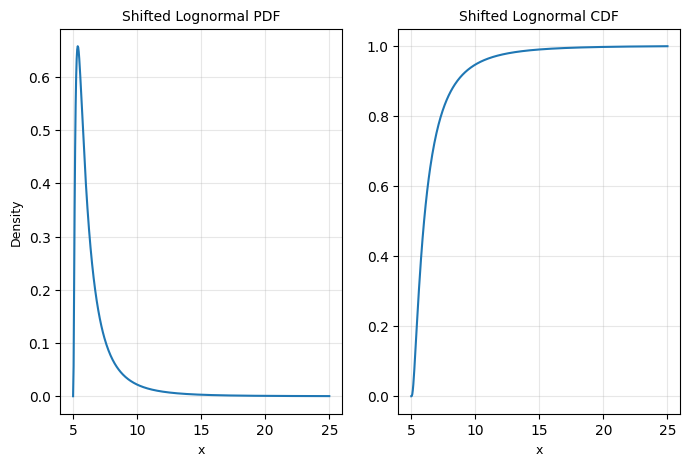

In [ ]:
# ============================================================
# Shifted Lognormal Distribution (3-PARAMETER VERSION)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# Lognormal parameters
mu = 0
sigma = 1

# Shift parameter (location)
shift = 5   # moves the entire distribution to the right

# Grid (must start at the shift)
x = np.linspace(shift, shift + 20, 500)

# PDF and CDF of shifted lognormal
pdf_vals = lognorm.pdf(x, s=sigma, scale=np.exp(mu), loc=shift)
cdf_vals = lognorm.cdf(x, s=sigma, scale=np.exp(mu), loc=shift)

# --- Create figure properly so export_plot works ---
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

# ============================================================
# LEFT: PDF
# ============================================================
axes[0].plot(x, pdf_vals)
axes[0].set_title("Shifted Lognormal PDF", fontsize=10)
axes[0].set_xlabel("x", fontsize=9)
axes[0].set_ylabel("Density", fontsize=9)
axes[0].grid(True, alpha=0.3)

# ============================================================
# RIGHT: CDF
# ============================================================
axes[1].plot(x, cdf_vals)
axes[1].set_title("Shifted Lognormal CDF", fontsize=10)
axes[1].set_xlabel("x", fontsize=9)
axes[1].set_ylabel("")  # remove y-label for second column
axes[1].grid(True, alpha=0.3)

plt.show()
export_plot(fig, "sim_shifted_lognormal")

### Shifted Student's t Distribution

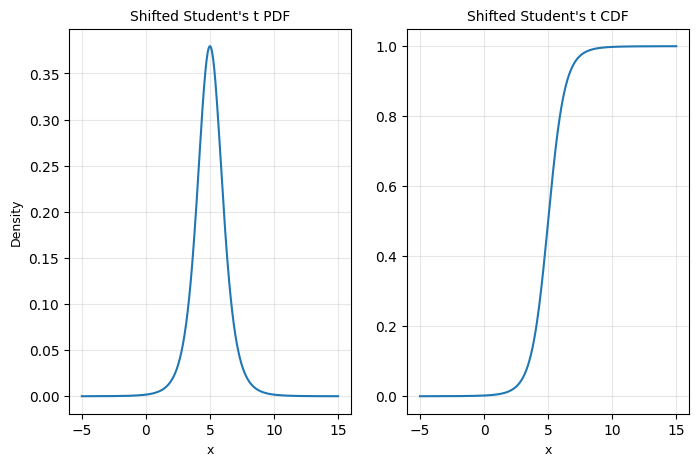

In [ ]:
# ============================================================
# Shifted Student's t Distribution (3-PARAMETER VERSION)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

# Student's t parameters
df = 5          # degrees of freedom
scale = 1.0     # scale parameter

# Shift parameter (location)
shift = 5       # moves the entire distribution to the right

# Grid
x = np.linspace(shift - 10, shift + 10, 500)

# PDF and CDF of shifted Student's t
pdf_vals = t.pdf((x - shift) / scale, df=df) / scale
cdf_vals = t.cdf((x - shift) / scale, df=df)

# --- Create figure properly so export_plot works ---
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

# ============================================================
# LEFT: PDF
# ============================================================
axes[0].plot(x, pdf_vals)
axes[0].set_title("Shifted Student's t PDF", fontsize=10)
axes[0].set_xlabel("x", fontsize=9)
axes[0].set_ylabel("Density", fontsize=9)
axes[0].grid(True, alpha=0.3)

# ============================================================
# RIGHT: CDF
# ============================================================
axes[1].plot(x, cdf_vals)
axes[1].set_title("Shifted Student's t CDF", fontsize=10)
axes[1].set_xlabel("x", fontsize=9)
axes[1].set_ylabel("")  # remove y-label for second column
axes[1].grid(True, alpha=0.3)

plt.show()

export_plot(fig, "sim_shifted_students_t")

## Comparing Distributions

### Relationships between Common Probability Distributions

#### Special Cases: One distribution is a restricted version of the other

| Smaller Distribution | Larger Distribution | Relationship |
|---|---|---|
| Bernoulli ($p$) | Binomial ($n, p$) | A Bernoulli is a Binomial with exactly $n=1$ trial. |
| Geometric ($p$) | Negative Binomial ($r, p$) | A Geometric is a Negative Binomial with exactly $r=1$ success. |
| Exponential ($\lambda$) | Gamma ($k, \theta$) | An Exponential is a Gamma with a shape of $k=1$. |
| Exponential ($\lambda=0.5$) | Chi-squared ($\nu$) | A Chi-squared with $\nu=2$ degrees of freedom is Exponential. |
| Uniform (0, 1) | Beta ($\alpha, \beta$) | A Beta with $\alpha=1, \beta=1$ is a flat Uniform distribution. |


#### Convergence: One distribution becomes another as a parameter reaches a limit

| Starting Distribution | Target Distribution | Relationship |
|---|---|---|
| Binomial | Poisson | As $n \to \infty$ and $p \to 0$ (Law of Rare Events). |
| Negative Binomial | Poisson | As $r \to \infty$ and $p \to 1$ while the mean $\mu$ stays constant. |
| Student's $t$ | Normal | As the degrees of freedom $\nu \to \infty$. |
| Binomial | Normal | As the number of trials $n \to \infty$ (De Moivre–Laplace theorem). |

#### Transformations: Converting one distribution to another using a mathematical function

| Input Distribution | Output Distribution | Relationship |
|---|---|---|
| Log-Normal | Normal | Taking the natural log of the variable makes it Normal. |
| Normal ($X, Y$) | Cauchy | The ratio $X/Y$ of two standard Normal variables is Cauchy. |
| Rayleigh | Chi-squared | Squaring a Rayleigh variable yields a Chi-squared with $\nu=2$. |

#### Analogues: The discrete version vs. its continuous counterpart

| Discrete Version | Continuous Version | Shared Property |
|---|---|---|
| Geometric | Exponential | Both are the only memoryless distributions. |
| Negative Binomial | Gamma | Both represent additive waiting times (sums of independent stages). |

### Symmetric vs Skewed

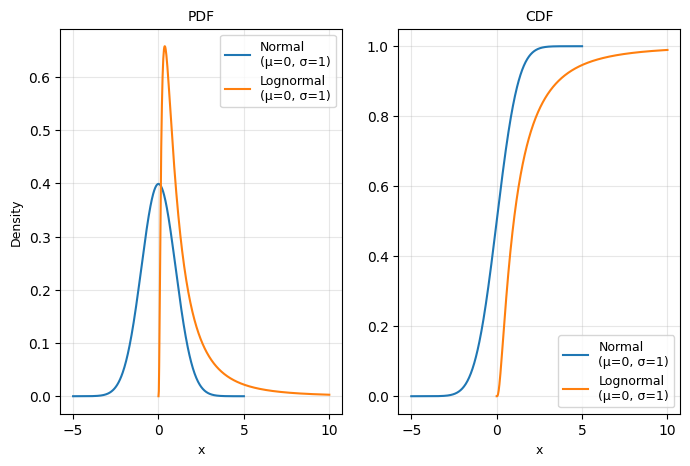

In [ ]:
# ============================================================
# SYMMETRIC (Normal) vs SKEWED (Lognormal)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Normal parameters
mu_n = 0
sigma_n = 1

# Lognormal parameters (same μ, σ for fair comparison)
mu_l = 0
sigma_l = 1

# Grids
grid_normal = np.linspace(-5, 5, 500)
grid_lognormal = np.linspace(0, 10, 500)

# --- Create figure properly so export_plot works ---
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

# ============================================================
# LEFT: PDFs
# ============================================================
axes[0].plot(
    grid_normal,
    stats.norm.pdf(grid_normal, loc=mu_n, scale=sigma_n),
    label="Normal\n(μ=0, σ=1)"
)

axes[0].plot(
    grid_lognormal,
    stats.lognorm.pdf(grid_lognormal, s=sigma_l, scale=np.exp(mu_l)),
    label="Lognormal\n(μ=0, σ=1)"
)

axes[0].set_title("PDF", fontsize=10)
axes[0].set_xlabel("x", fontsize=9)
axes[0].set_ylabel("Density", fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9)

# ============================================================
# RIGHT: CDFs
# ============================================================
axes[1].plot(
    grid_normal,
    stats.norm.cdf(grid_normal, loc=mu_n, scale=sigma_n),
    label="Normal\n(μ=0, σ=1)"
)

axes[1].plot(
    grid_lognormal,
    stats.lognorm.cdf(grid_lognormal, s=sigma_l, scale=np.exp(mu_l)),
    label="Lognormal\n(μ=0, σ=1)"
)

axes[1].set_title("CDF", fontsize=10)
axes[1].set_xlabel("x", fontsize=9)
axes[1].set_ylabel("")  # remove y-label for second column
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)

plt.show()
export_plot(fig, "sim_symmetric_vs_skewed")

### Tail Weight

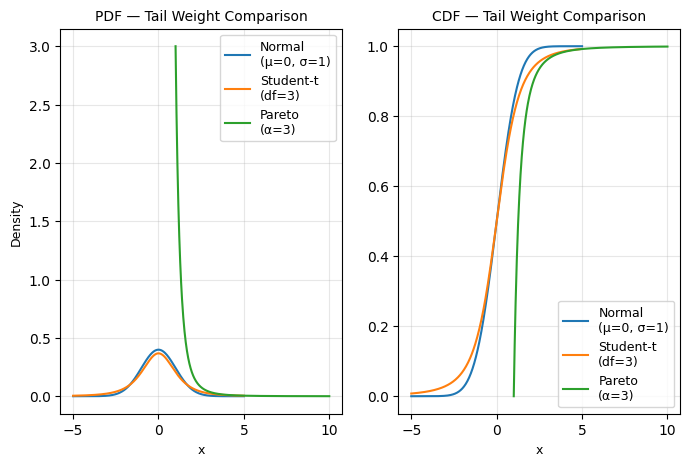

In [ ]:
# ============================================================
# TAIL WEIGHT
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Normal parameters
mu_n = 0
sigma_n = 1

# Student‑t parameters
df_t = 3

# Pareto parameters
alpha_p = 3
xm_p = 1

# Grids
grid_normal = np.linspace(-5, 5, 500)
grid_student = np.linspace(-5, 5, 500)
grid_pareto = np.linspace(1, 10, 500)   # Pareto support: x >= xm

# --- Create figure properly so export_plot works ---
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

# ============================================================
# LEFT: PDFs
# ============================================================
axes[0].plot(
    grid_normal,
    stats.norm.pdf(grid_normal, loc=mu_n, scale=sigma_n),
    label="Normal\n(μ=0, σ=1)"
)

axes[0].plot(
    grid_student,
    stats.t.pdf(grid_student, df=df_t),
    label="Student‑t\n(df=3)"
)

axes[0].plot(
    grid_pareto,
    stats.pareto.pdf(grid_pareto, b=alpha_p, scale=xm_p),
    label="Pareto\n(α=3)"
)

axes[0].set_title("PDF — Tail Weight Comparison", fontsize=10)
axes[0].set_xlabel("x", fontsize=9)
axes[0].set_ylabel("Density", fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9)

# ============================================================
# RIGHT: CDFs
# ============================================================
axes[1].plot(
    grid_normal,
    stats.norm.cdf(grid_normal, loc=mu_n, scale=sigma_n),
    label="Normal\n(μ=0, σ=1)"
)

axes[1].plot(
    grid_student,
    stats.t.cdf(grid_student, df=df_t),
    label="Student‑t\n(df=3)"
)

axes[1].plot(
    grid_pareto,
    stats.pareto.cdf(grid_pareto, b=alpha_p, scale=xm_p),
    label="Pareto\n(α=3)"
)

axes[1].set_title("CDF — Tail Weight Comparison", fontsize=10)
axes[1].set_xlabel("x", fontsize=9)
axes[1].set_ylabel("")  # remove y-label for second column
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)

plt.show()
export_plot(fig, "sim_tail_weight")

### Unimodal vs Multimodal

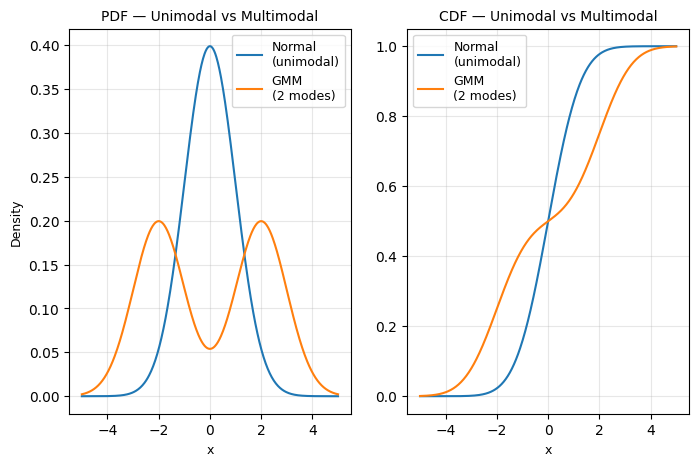

In [ ]:
# ============================================================
# UNIMODAL vs MULTIMODAL
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Normal parameters
mu_n = 0
sigma_n = 1

# GMM parameters (2 modes)
w1, w2 = 0.5, 0.5
mu1, sigma1 = -2, 1
mu2, sigma2 = 2, 1

# Grid
grid = np.linspace(-5, 5, 500)

# Analytical GMM PDF
gmm_pdf = (
    w1 * stats.norm.pdf(grid, loc=mu1, scale=sigma1) +
    w2 * stats.norm.pdf(grid, loc=mu2, scale=sigma2)
)

# Analytical GMM CDF
gmm_cdf = (
    w1 * stats.norm.cdf(grid, loc=mu1, scale=sigma1) +
    w2 * stats.norm.cdf(grid, loc=mu2, scale=sigma2)
)

# --- Create figure properly so export_plot works ---
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

# ============================================================
# LEFT: PDFs
# ============================================================
axes[0].plot(
    grid,
    stats.norm.pdf(grid, loc=mu_n, scale=sigma_n),
    label="Normal\n(unimodal)"
)

axes[0].plot(
    grid,
    gmm_pdf,
    label="GMM\n(2 modes)"
)

axes[0].set_title("PDF — Unimodal vs Multimodal", fontsize=10)
axes[0].set_xlabel("x", fontsize=9)
axes[0].set_ylabel("Density", fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9)

# ============================================================
# RIGHT: CDFs
# ============================================================
axes[1].plot(
    grid,
    stats.norm.cdf(grid, loc=mu_n, scale=sigma_n),
    label="Normal\n(unimodal)"
)

axes[1].plot(
    grid,
    gmm_cdf,
    label="GMM\n(2 modes)"
)

axes[1].set_title("CDF — Unimodal vs Multimodal", fontsize=10)
axes[1].set_xlabel("x", fontsize=9)
axes[1].set_ylabel("")  # remove y-label for second column
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)

plt.show()
export_plot(fig, "sim_unimodal_vs_multimodal")

### Bounded vs Unbounded

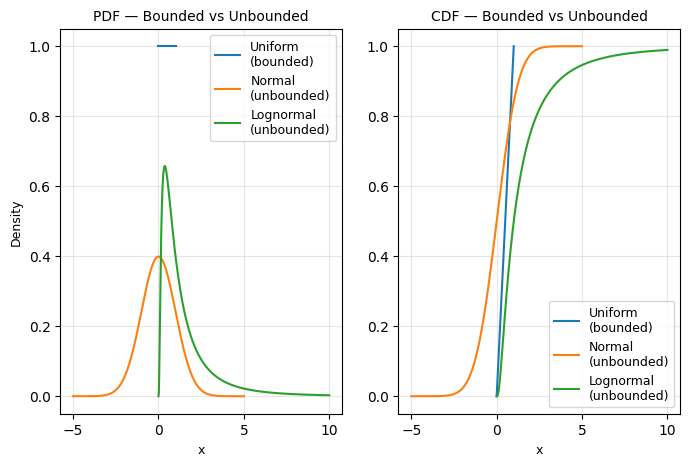

In [ ]:
# ============================================================
# BOUNDED vs UNBOUNDED
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Uniform parameters
a, b = 0, 1

# Normal parameters
mu_n = 0
sigma_n = 1

# Lognormal parameters
mu_l = 0
sigma_l = 1

# Grids
grid_uniform = np.linspace(0, 1, 500)
grid_normal = np.linspace(-5, 5, 500)
grid_lognormal = np.linspace(0, 10, 500)

# --- Create figure properly so export_plot works ---
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

# ============================================================
# LEFT: PDFs
# ============================================================
axes[0].plot(
    grid_uniform,
    stats.uniform.pdf(grid_uniform, loc=a, scale=b - a),
    label="Uniform\n(bounded)"
)

axes[0].plot(
    grid_normal,
    stats.norm.pdf(grid_normal, loc=mu_n, scale=sigma_n),
    label="Normal\n(unbounded)"
)

axes[0].plot(
    grid_lognormal,
    stats.lognorm.pdf(grid_lognormal, s=sigma_l, scale=np.exp(mu_l)),
    label="Lognormal\n(unbounded)"
)

axes[0].set_title("PDF — Bounded vs Unbounded", fontsize=10)
axes[0].set_xlabel("x", fontsize=9)
axes[0].set_ylabel("Density", fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9)

# ============================================================
# RIGHT: CDFs
# ============================================================
axes[1].plot(
    grid_uniform,
    stats.uniform.cdf(grid_uniform, loc=a, scale=b - a),
    label="Uniform\n(bounded)"
)

axes[1].plot(
    grid_normal,
    stats.norm.cdf(grid_normal, loc=mu_n, scale=sigma_n),
    label="Normal\n(unbounded)"
)

axes[1].plot(
    grid_lognormal,
    stats.lognorm.cdf(grid_lognormal, s=sigma_l, scale=np.exp(mu_l)),
    label="Lognormal\n(unbounded)"
)

axes[1].set_title("CDF — Bounded vs Unbounded", fontsize=10)
axes[1].set_xlabel("x", fontsize=9)
axes[1].set_ylabel("")  # remove y-label for second column
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)

plt.show()
export_plot(fig, "sim_bounded_vs_unbounded")

### Continuous vs Discrete Waiting Times

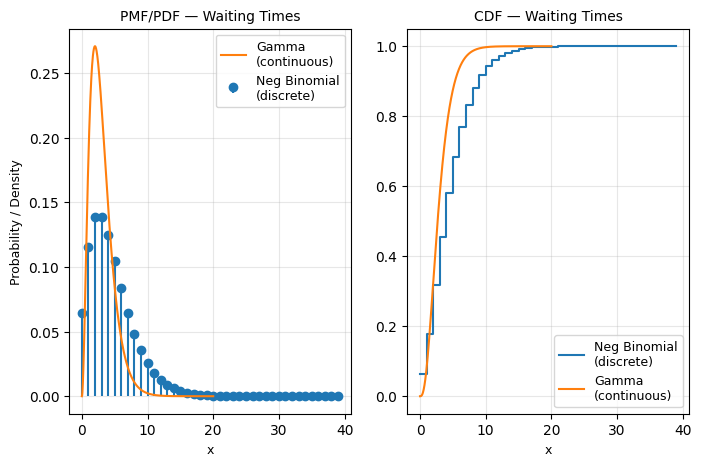

In [ ]:
# ============================================================
# CONTINUOUS vs DISCRETE WAITING TIMES
# Gamma (continuous) vs Negative Binomial (discrete)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Parameters
r = 3            # number of events
p = 0.4          # success probability for Negative Binomial
lambda_rate = 1  # rate for Gamma (mean waiting time = r / lambda)

# Grids
grid_nb = np.arange(0, 40)            # discrete support
grid_gamma = np.linspace(0, 20, 500)  # continuous support

# --- Create figure properly so export_plot works ---
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

# ============================================================
# LEFT: PMF/PDF
# ============================================================
axes[0].stem(
    grid_nb,
    stats.nbinom.pmf(grid_nb, r, p),
    linefmt="C0-",
    markerfmt="C0o",
    basefmt=" ",
    label="Neg Binomial\n(discrete)"
)

axes[0].plot(
    grid_gamma,
    stats.gamma.pdf(grid_gamma, a=r, scale=1/lambda_rate),
    label="Gamma\n(continuous)"
)

axes[0].set_title("PMF/PDF — Waiting Times", fontsize=10)
axes[0].set_xlabel("x", fontsize=9)
axes[0].set_ylabel("Probability / Density", fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9)

# ============================================================
# RIGHT: CDFs
# ============================================================
axes[1].step(
    grid_nb,
    stats.nbinom.cdf(grid_nb, r, p),
    where="post",
    label="Neg Binomial\n(discrete)"
)

axes[1].plot(
    grid_gamma,
    stats.gamma.cdf(grid_gamma, a=r, scale=1/lambda_rate),
    label="Gamma\n(continuous)"
)

axes[1].set_title("CDF — Waiting Times", fontsize=10)
axes[1].set_xlabel("x", fontsize=9)
axes[1].set_ylabel("")  # remove y-label for second column
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)

plt.show()
export_plot(fig, "sim_waiting_times")

### Memoryless vs Aging

**Memoryless distributions**
- Future survival does not depend on past survival time.
- Defined by: P(X > s + t | X > s) = P(X > t)
- Only the exponential distribution has this property (continuous case).  

**Aging distributions**
- Failure probability changes as time passes.
- Lognormal → increasing hazard (risk grows with age).
- Pareto → decreasing hazard (early failures common, survivors become stronger).  

**Interpretation**
- Memoryless → “no wear‑out, no fatigue.”
- Aging → “history matters; survival changes future risk.”


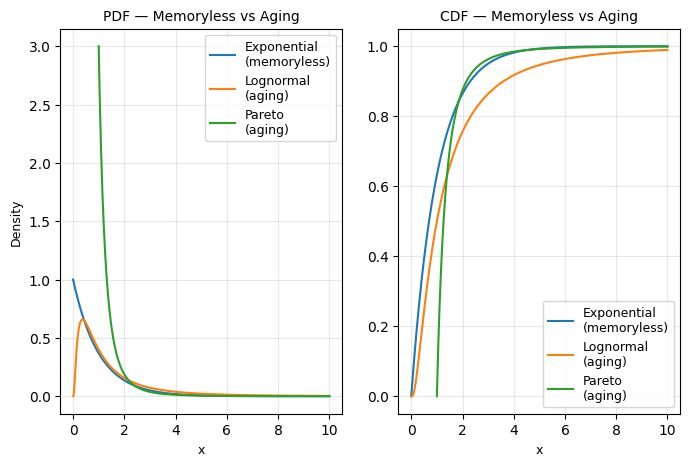

In [ ]:
# ============================================================
# MEMORYLESS vs AGING
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Exponential parameters
lambda_exp = 1

# Lognormal parameters
mu_l = 0
sigma_l = 1

# Pareto parameters
alpha_p = 3
xm_p = 1

# Grids
grid_exp = np.linspace(0, 10, 500)
grid_lognormal = np.linspace(0, 10, 500)
grid_pareto = np.linspace(1, 10, 500)   # Pareto support: x >= xm

# --- Create figure properly so export_plot works ---
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

# ============================================================
# LEFT: PDFs
# ============================================================
axes[0].plot(
    grid_exp,
    stats.expon.pdf(grid_exp, scale=1/lambda_exp),
    label="Exponential\n(memoryless)"
)

axes[0].plot(
    grid_lognormal,
    stats.lognorm.pdf(grid_lognormal, s=sigma_l, scale=np.exp(mu_l)),
    label="Lognormal\n(aging)"
)

axes[0].plot(
    grid_pareto,
    stats.pareto.pdf(grid_pareto, b=alpha_p, scale=xm_p),
    label="Pareto\n(aging)"
)

axes[0].set_title("PDF — Memoryless vs Aging", fontsize=10)
axes[0].set_xlabel("x", fontsize=9)
axes[0].set_ylabel("Density", fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9)

# ============================================================
# RIGHT: CDFs
# ============================================================
axes[1].plot(
    grid_exp,
    stats.expon.cdf(grid_exp, scale=1/lambda_exp),
    label="Exponential\n(memoryless)"
)

axes[1].plot(
    grid_lognormal,
    stats.lognorm.cdf(grid_lognormal, s=sigma_l, scale=np.exp(mu_l)),
    label="Lognormal\n(aging)"
)

axes[1].plot(
    grid_pareto,
    stats.pareto.cdf(grid_pareto, b=alpha_p, scale=xm_p),
    label="Pareto\n(aging)"
)

axes[1].set_title("CDF — Memoryless vs Aging", fontsize=10)
axes[1].set_xlabel("x", fontsize=9)
axes[1].set_ylabel("")  # remove y-label for second column
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)

plt.show()
export_plot(fig, "sim_memoryless_vs_aging")

## Aging Behavior Through Survival Curves and Hazard Rates

### Constructing Survival and Hazard Curves


1. Generate random samples from each distribution (Exponential, Lognormal, Pareto, etc.).
2. Compute the theoretical PDF for each distribution.
3. Compute the CDF (empirical for sample‑based distributions, theoretical when available).
4. Convert CDF to survival using S(x)=1-\mathrm{CDF}(x).
5. Compute the hazard rate using h(x)=f(x)/S(x).
6. Plot the survival curves, hazard rates, and PDFs for comparison.



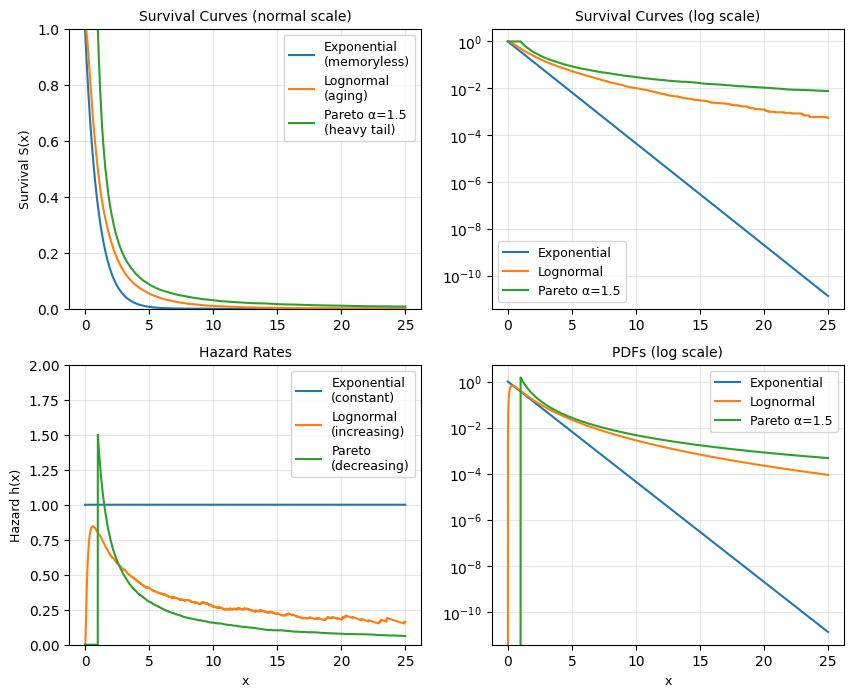

In [ ]:
# ============================================================
# Survival Curves, Hazard Rates, and PDFs (x < 25 everywhere)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
n = 20000

# ------------------------------------------------------------
# Generate sample data
# ------------------------------------------------------------
exp_data = np.random.exponential(scale=1, size=n)
lognorm_data = np.random.lognormal(mean=0, sigma=1, size=n)

# Heavier-tailed Pareto (alpha = 1.5)
pareto_alpha = 1.5
pareto_data = np.random.pareto(a=pareto_alpha, size=n) + 1

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def cdf(x, grid):
    return np.searchsorted(np.sort(x), grid, side="right") / len(x)

def survival(cdf_vals):
    return 1 - cdf_vals

def hazard(pdf_vals, survival_vals):
    return pdf_vals / np.maximum(survival_vals, 1e-12)

# ------------------------------------------------------------
# Grids
# ------------------------------------------------------------
grid = np.linspace(0, 40, 5000)
mask = grid < 25

# ------------------------------------------------------------
# True PDFs
# ------------------------------------------------------------
pdf_exp = stats.expon(scale=1).pdf(grid)
pdf_lognorm = stats.lognorm(s=1, scale=np.exp(0)).pdf(grid)
pdf_pareto = stats.pareto(b=pareto_alpha, scale=1).pdf(grid)

# ------------------------------------------------------------
# Survival functions
# ------------------------------------------------------------
S_exp = stats.expon(scale=1).sf(grid)

cdf_lognorm = cdf(lognorm_data, grid)
cdf_pareto = cdf(pareto_data, grid)

S_lognorm = survival(cdf_lognorm)
S_pareto = survival(cdf_pareto)

# ------------------------------------------------------------
# Hazard rates
# ------------------------------------------------------------
h_exp = hazard(pdf_exp, S_exp)
h_lognorm = hazard(pdf_lognorm, S_lognorm)
h_pareto = hazard(pdf_pareto, S_pareto)

# ============================================================
# Plotting
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# ------------------------------------------------------------
# Survival curves (normal scale)
# ------------------------------------------------------------
axes[0, 0].plot(grid[mask], S_exp[mask], label="Exponential\n(memoryless)")
axes[0, 0].plot(grid[mask], S_lognorm[mask], label="Lognormal\n(aging)")
axes[0, 0].plot(grid[mask], S_pareto[mask], label=f"Pareto α={pareto_alpha}\n(heavy tail)")
axes[0, 0].set_title("Survival Curves (normal scale)", fontsize=10)
axes[0, 0].set_ylabel("Survival S(x)", fontsize=9)
axes[0, 0].set_ylim(0, 1)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=9)

# ------------------------------------------------------------
# Survival curves (log scale)
# ------------------------------------------------------------
axes[0, 1].plot(grid[mask], S_exp[mask], label="Exponential")
axes[0, 1].plot(grid[mask], S_lognorm[mask], label="Lognormal")
axes[0, 1].plot(grid[mask], S_pareto[mask], label=f"Pareto α={pareto_alpha}")
axes[0, 1].set_yscale("log")
axes[0, 1].set_title("Survival Curves (log scale)", fontsize=10)
axes[0, 1].set_ylabel("")  # remove y-label for right column
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(fontsize=9)

# ------------------------------------------------------------
# Hazard rates (x < 25)
# ------------------------------------------------------------
axes[1, 0].plot(grid[mask], h_exp[mask], label="Exponential\n(constant)")
axes[1, 0].plot(grid[mask], h_lognorm[mask], label="Lognormal\n(increasing)")
axes[1, 0].plot(grid[mask], h_pareto[mask], label="Pareto\n(decreasing)")
axes[1, 0].set_ylim(0, 2)
axes[1, 0].set_title("Hazard Rates", fontsize=10)
axes[1, 0].set_xlabel("x", fontsize=9)
axes[1, 0].set_ylabel("Hazard h(x)", fontsize=9)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(fontsize=9)

# ------------------------------------------------------------
# PDFs (log scale)
# ------------------------------------------------------------
axes[1, 1].plot(grid[mask], pdf_exp[mask], label="Exponential")
axes[1, 1].plot(grid[mask], pdf_lognorm[mask], label="Lognormal")
axes[1, 1].plot(grid[mask], pdf_pareto[mask], label=f"Pareto α={pareto_alpha}")
axes[1, 1].set_yscale("log")
axes[1, 1].set_title("PDFs (log scale)", fontsize=10)
axes[1, 1].set_xlabel("x", fontsize=9)
axes[1, 1].set_ylabel("")  # remove y-label for right column
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(fontsize=9)

# ------------------------------------------------------------
# AXIS CLEANUP RULES
# ------------------------------------------------------------

# Remove x-labels from top row
axes[0, 0].set_xlabel("")
axes[0, 1].set_xlabel("")

plt.show()
export_plot(fig, "sim_hazard_and_survival")

### Summary Table - Survival Curves and Hazard Rates

| **Distribution** | **Survival Curve + Hazard Behavior** | **Behavioral Fingerprint** |
|------------------|---------------------------------------|-----------------------------|
| **Exponential**  | **Survival:** Straight line on log scale (fast decay)<br>**Hazard:** Constant | Memoryless — <br>past survival does not affect future risk |
| **Lognormal**    | **Survival:** Curved decay; moderately heavy tail<br>**Hazard:** Low → rises → peaks → slowly declines | Aging system — <br>risk increases with time before tapering |
| **Pareto**       | **Survival:** Very slow decay; dominant heavy tail<br>**Hazard:** High early → steadily decreases | Front‑loaded risk — <br>extreme events remain plausible after a long time |

## Multivariate Distributions and Variable Relationships

### Simulation Data

In [ ]:
# ============================================================
# Simulation Data: Correlated Pair, Independent Variable, Nonlinear Variable
# ============================================================

import numpy as np
import pandas as pd

np.random.seed(42)

n = 1000

# Correlated pair (negative correlation)
X = np.random.normal(0, 1, n)
epsilon = np.random.normal(0, 0.5, n)
Y = -0.7 * X + epsilon   # now negatively correlated with X

# Independent variable
Z = np.random.normal(0, 1, n)

# Nonlinear relationship
eta = np.random.normal(0, 0.3, n)
W = X**2 + eta

df = pd.DataFrame({"X": X, "Y": Y, "Z": Z, "W": W})
df.head()


,X,Y,Z,W
0,0.496714,0.351978,-0.675178,-0.325617
1,-0.138264,0.559102,-0.144519,-0.238998
2,0.647689,-0.423567,-0.792420,0.295419
3,1.523030,-1.389589,-0.307962,2.885926
4,-0.234153,0.513019,-1.893615,0.221794


### Joint Distributions

/usr/local/lib/python3.12/dist-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(


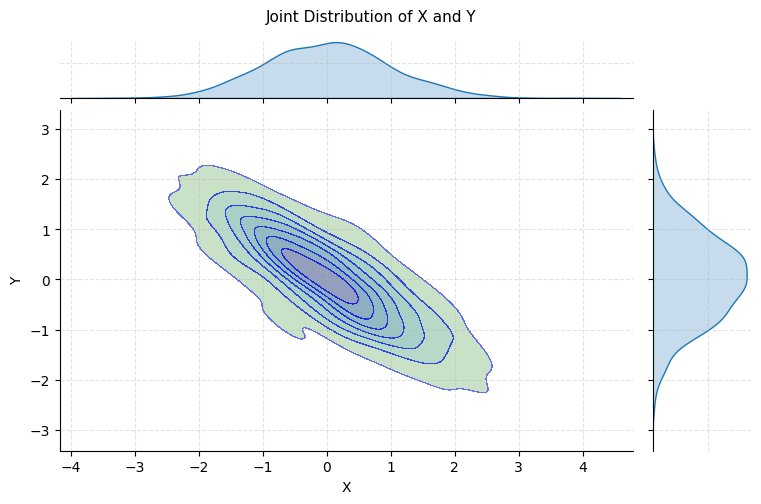

In [ ]:
# ============================================================
# Joint Distributions: fewer, darker contour lines
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

g = sns.jointplot(
    data=df,
    x="X",
    y="Y",
    kind="kde",
    fill=True,
    cmap="crest",
    levels=8,
    linewidths=1,
    alpha=0.5,
)

# Set figure size
g.fig.set_size_inches(8, 5)

# Darken only the JOINT contour lines (not marginal histograms)
for artist in g.ax_joint.collections:
    if hasattr(artist, "get_paths"):   # ensures it's a contour
        artist.set_edgecolor("blue")
        artist.set_linewidth(0.1)

# Gridlines
g.ax_joint.grid(True, linestyle="--", alpha=0.35)
g.ax_marg_x.grid(True, linestyle="--", alpha=0.35)
g.ax_marg_y.grid(True, linestyle="--", alpha=0.35)

# Title + fix for disappearing title
g.fig.suptitle("Joint Distribution of X and Y", fontsize=11)
g.fig.subplots_adjust(top=0.92)

plt.show()
export_plot(g.fig, "sim_joint_distribution")

### Covariance and Correlation

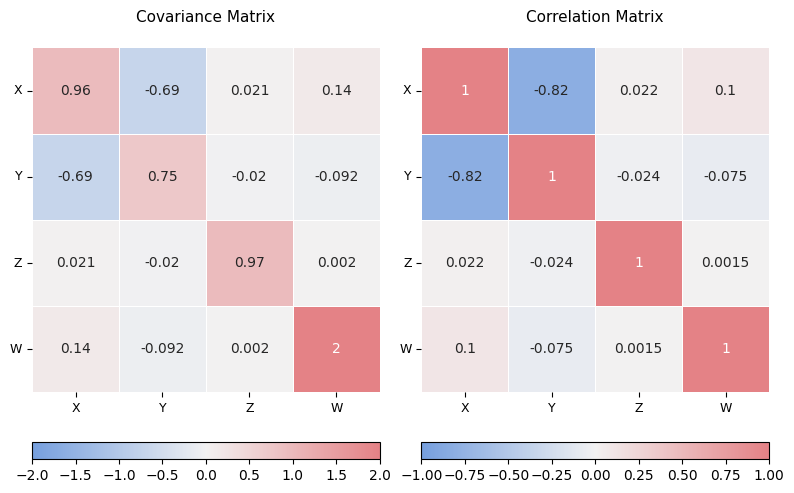

In [ ]:
# ============================================================
# Covariance and correlation: Side-by-side Heatmaps (light colors)
# ============================================================

import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt

# moderately lively, not too strong
pastel_lively = sns.diverging_palette(
    250, 10,          # blue → red
    s=65,             # saturation
    l=65,             # lightness
    center="light",
    as_cmap=True
)

fig, axes = plt.subplots(1, 2, figsize=(8, 5))

# ------------------------------------------------------------
# Covariance heatmap
# ------------------------------------------------------------
cov = df[["X", "Y", "Z", "W"]].cov()

hm1 = sns.heatmap(
    cov,
    annot=True,
    cmap=pastel_lively,
    linewidths=0.5,
    ax=axes[0],
    cbar=False,
    vmin=-2,
    vmax=2
)

axes[0].set_title("Covariance Matrix", y=1.05, fontsize=11)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0, fontsize=9)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=9)

fig.colorbar(
    hm1.collections[0],
    ax=axes[0],
    orientation="horizontal",
    fraction=0.046,
    pad=0.12
)

# ------------------------------------------------------------
# Correlation heatmap
# ------------------------------------------------------------
corr = df[["X", "Y", "Z", "W"]].corr()

hm2 = sns.heatmap(
    corr,
    annot=True,
    cmap=pastel_lively,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=axes[1],
    cbar=False
)

axes[1].set_title("Correlation Matrix", y=1.05, fontsize=11)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0, fontsize=9)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=9)

fig.colorbar(
    hm2.collections[0],
    ax=axes[1],
    orientation="horizontal",
    fraction=0.046,
    pad=0.12
)

plt.tight_layout()
plt.show()
export_plot(fig, "sim_covariance_correlation")

### Conditional Distributions

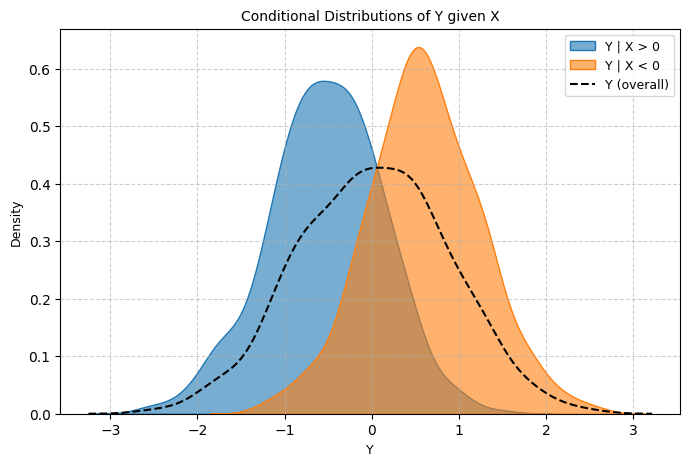

In [ ]:
# ============================================================
# Conditional distributions: Y | X > 0 vs Y | X < 0 (+ overall Y)
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 5))

sns.kdeplot(df.loc[df["X"] > 0, "Y"], label="Y | X > 0", fill=True, alpha=0.6)
sns.kdeplot(df.loc[df["X"] < 0, "Y"], label="Y | X < 0", fill=True, alpha=0.6)
sns.kdeplot(df["Y"], label="Y (overall)", color="black", linestyle="--")

plt.title("Conditional Distributions of Y given X", fontsize=10)
plt.xlabel("Y", fontsize=9)
plt.ylabel("Density", fontsize=9)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=9)

plt.show()
export_plot(fig, "sim_conditional_distributions")

### Independence

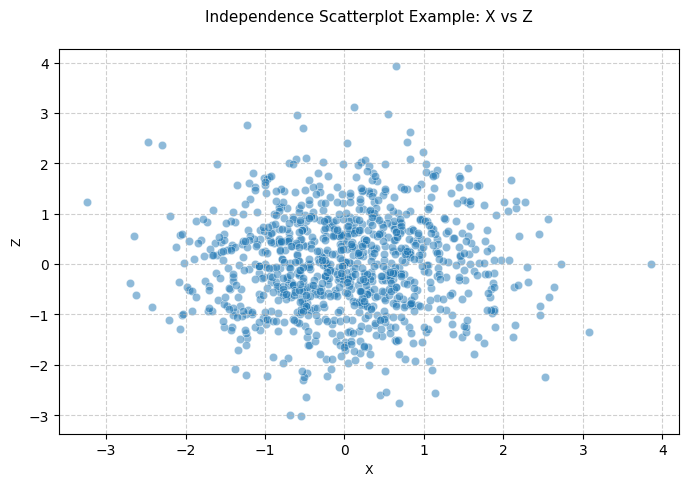

In [ ]:
# ============================================================
# Independence: Scatterplot of X vs Z
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="X", y="Z", alpha=0.5)

plt.title("Independence Scatterplot Example: X vs Z", y=1.05, fontsize=11)
plt.xlabel("X", fontsize=9)
plt.ylabel("Z", fontsize=9)
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()
export_plot(fig, "sim_independence_scatterplot")

### Marginal Distributions

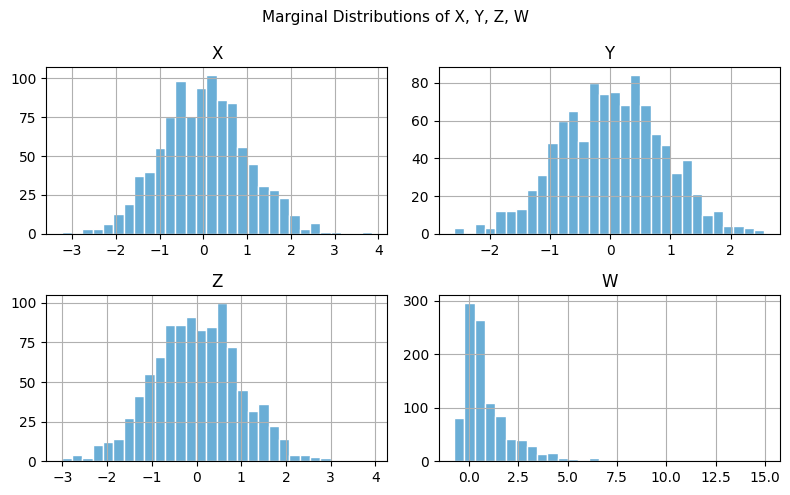

In [ ]:
# ============================================================
# Marginal Distributions: histograms of X, Y, Z, W
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(8, 5))

pale_blue = sns.color_palette("Blues", 5)[2]

df[["X", "Y", "Z", "W"]].hist(
    bins=30,
    color=pale_blue,
    edgecolor="white",
    ax=axes
)

fig.suptitle("Marginal Distributions of X, Y, Z, W", fontsize=11)
plt.tight_layout()
plt.show()
export_plot(fig, "sim_marginal_distributions")

### Summary: Pairwise Relationships at a Glance

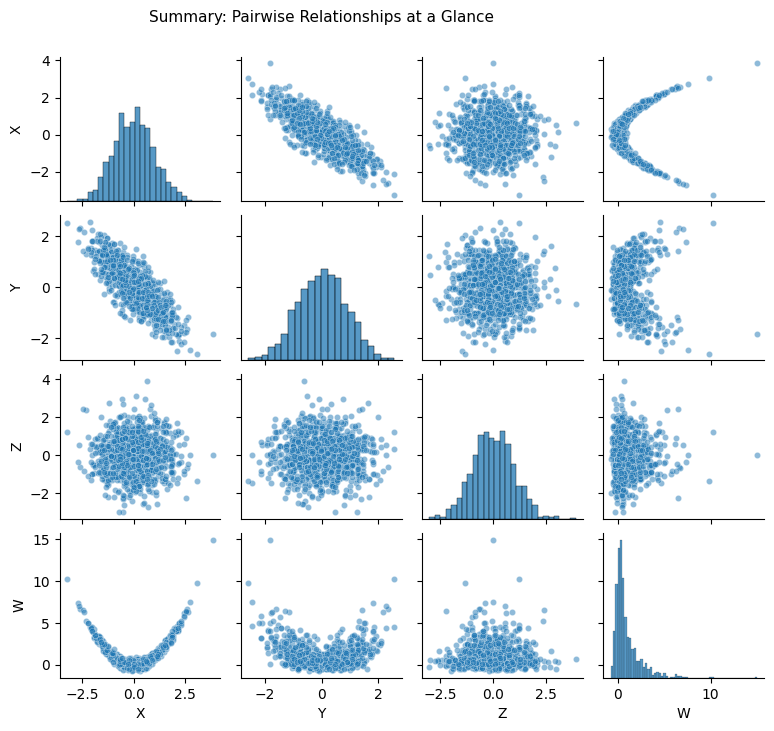

In [ ]:
# ============================================================
# Summary: Pairwise Relationships at a Glance
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

g = sns.pairplot(
    df[["X", "Y", "Z", "W"]],
    diag_kind="hist",
    plot_kws={"alpha": 0.5, "s": 20},
    height=1.6,
    aspect=1.0
)

# Set figure size
g.fig.set_size_inches(8, 7)

# Centered title INSIDE the grid (top middle axis)
top_middle_ax = g.axes[0, 1]   # middle of the top row
top_middle_ax.set_title(
    "Summary: Pairwise Relationships at a Glance",
    fontsize=11,
    pad=25,
    loc="center"
)

plt.show()
export_plot(g.fig, "sim_pairwise_relationships", height=7)